<a target="_blank" href="https://colab.research.google.com/github/LPolyakova/Linear_Algebra_for_CS_students/blob/main/CP/LA_CP_05_Euclidean_spaces.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# ЛА-Практика програмування-05. Евклідові простори

In [1]:
# these imports may be useful

import pandas as pd
from scipy import linalg
from scipy.spatial.distance import pdist, cdist
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


 #### Деякі інструменти, які стануть у нагоді 

In [2]:
# these tools may be useful

# inner product
e1 = np.array([1,2,2])
e2 = np.array([2,3,-4])
p = np.dot(e1, e2)
print(f'''Inner product of vectors e1={e1} and e2={e2} is {p}''')
print('___________________________________')

# calculate distance between points
metric = 'cosine'
d = cdist([e1], [e2], metric=metric) #array of pairwise distances, here of the shape (1,1) 
print(f'''The {metric} distance between e1={e1} and e2={e2} is  {d[0][0]}''')
print('___________________________________')


# vector norm, matrix norm
A = np.array([[1,1], [0,1]])
e1_norm = np.linalg.norm(e1) # default Euclidean norm
A_norm = np.linalg.norm(A)   # default Frobenius norm
print(f'''Euclidean norm of e1={e1} is {e1_norm}. \n Frobenius norm of A={A} is {A_norm}''')
print('___________________________________')


# qr decomposition
B = np.array([[1, 2, 2, 0], [1, 1, -6, 1], [3, 2, 1, 1]]) #originally have three 4-vectors.
Bt = B.T  #write them as columns of a matrix
q, r = np.linalg.qr(Bt)
print(f'''QR-decomposition of {Bt} is Q={q}, R={r}. \n
It means that the columns of Q form the orthonormal basis of the space spanned by original vectors''')


Inner product of vectors e1=[1 2 2] and e2=[ 2  3 -4] is 0
___________________________________
The cosine distance between e1=[1 2 2] and e2=[ 2  3 -4] is  1.0
___________________________________
Euclidean norm of e1=[1 2 2] is 3.0. 
 Frobenius norm of A=[[1 1]
 [0 1]] is 1.7320508075688772
___________________________________
QR-decomposition of [[ 1  1  3]
 [ 2  1  2]
 [ 2 -6  1]
 [ 0  1  1]] is Q=[[-0.33333333 -0.36514837  0.77067464]
 [-0.66666667 -0.54772256 -0.49543369]
 [-0.66666667  0.73029674  0.11009638]
 [-0.         -0.18257419  0.38533732]], R=[[-3.          3.         -3.        ]
 [ 0.         -5.47722558 -1.64316767]
 [ 0.          0.          1.81659021]]. 

It means that the columns of Q form the orthonormal basis of the space spanned by original vectors


## Вправи

💻  **5.1. Ортонормований базис.** Напишіть функцію, яка перевіряє, чи є базис, що його дано на вході, ортонормованим. Напишіть функцію, яка розкладає даний вектор за  даним ортонормованим базисом, шукаючи його проекції на базисні вектори за допомогою скалярних добутків. Протестуйте свої функції. Для тестування можна використовувати дані з задач математичного практикуму.

In [ ]:
#write your code here

💻  **5.2. Алгоритм Грама-Шмідта.**  Напишіть програму, яка здійснює для даної системи векторів (довільної кількості) у $\mathbb{R}^4$ процес ортогоналізації та виводить ортонормований базис лінійної оболонки даних векторів. Порівняйте свої результати з QR-розкладом матриці, що складається з координат даних векторів. Для знаходження QR-розкладу можна використовувати numpy.linalg.qr або scipy.linalg.qr.

In [ ]:
#write your code here

💻  **5.3. Матриця проекції.** Напишіть функцію, яка обчислює матрицю ортогональної проекції на підпростір, натягнутий на дані вектори. Протестуйте цю функцію на прикладах (можна взяти приклади з математичного практикуму). Проілюструйте дію функції.

In [ ]:
#write your code here

💻  **5.4. Розв'язання трикутників.** Напишіть програму, яка за заданими трьома точками площини (або тривимірного простору) 
1) Малює трикутник з вершинами у даних точках.
2) Обчислює довжини сторін трикутника.
3) Обчислює кути трикутника.

Використайте вбудовані функції, що обчислюють норми векторів та скалярні добутки. Також можна використати вбудовану функцію scipy.spatial.distance.pdist, що обчислює попарні відстані між точками й видає їх у вигляді списку або (якщо додатково застосувати функцію  squareform) у вигляді матриці.

# Аналіз трикутника: пояснення

**Вхідні дані:**

Задані три точки у вигляді списку:

\[
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3
\end{bmatrix}
\]

(або з координатами у просторі, тобто 3D).



### 1. Малювання трикутника

- Якщо точки задано у 2D, програма будує графік з підписаними вершинами.
- Трикутник малюється як ламана: `P1 → P2 → P3 → P1`, щоб замкнути контур.



### 2. Обчислення довжин сторін

- Використовується функція `pdist` з пакету `scipy` для обчислення попарних евклідових відстаней.
- Функція `squareform` перетворює список відстаней у симетричну матрицю.
- Сторони трикутника позначаються так:
  - `a = |P2 - P3|`
  - `b = |P1 - P3|`
  - `c = |P1 - P2|`



### 3. Обчислення кутів трикутника

- Для обчислення кута використовується формула косинуса:

cos(θ) = (b² + c² - a²) / (2bc)
де `a` — протилежна сторона до кута `θ`.

- Кути переводяться з радіан у градуси за допомогою `np.degrees`.
- Результат округлюється до двох знаків після коми.



✅ Після виконання функції виводяться:
- Довжини сторін трикутника.
- Значення трьох внутрішніх кутів (у градусах).
- Якщо координати 2D — також графік трикутника.


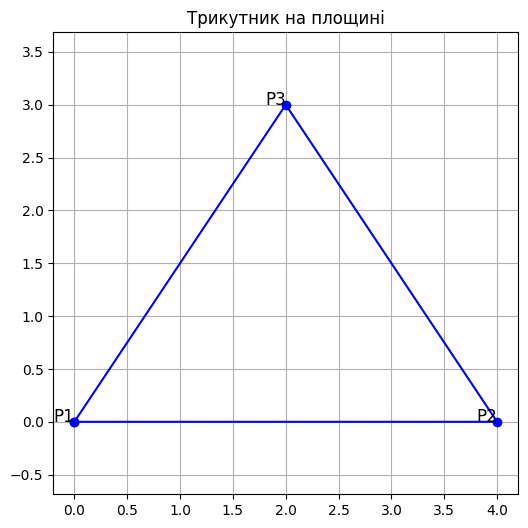


Довжини сторін трикутника:
a = |P2 - P3| = 3.6056
b = |P1 - P3| = 3.6056
c = |P1 - P2| = 4.0000

Кути трикутника (в градусах):
∠P1 = 56.31°
∠P2 = 56.31°
∠P3 = 67.38°


In [2]:
#write your code here
import pandas as pd
from scipy import linalg
from scipy.spatial.distance import pdist, squareform
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

def triangle_properties(points):
    """
    points: масив 3x2 або 3x3 (координати трьох точок на площині або у просторі)
    """

    # Перетворення у NumPy-масив
    points = np.array(points, dtype=float)

    # Перевірка розмірності
    if points.shape != (3, 2) and points.shape != (3, 3):
        print("Помилка: потрібно ввести рівно три точки у 2D або 3D.")
        return

    # 1) Малювання трикутника (для 2D)
    if points.shape[1] == 2:
        x = np.append(points[:, 0], points[0, 0])
        y = np.append(points[:, 1], points[0, 1])
        plt.figure(figsize=(6, 6))
        plt.plot(x, y, 'bo-')
        for i, (xi, yi) in enumerate(points):
            plt.text(xi, yi, f'P{i+1}', fontsize=12, ha='right')
        plt.title("Трикутник на площині")
        plt.grid(True)
        plt.axis('equal')
        plt.show()

    # 2) Обчислення довжин сторін
    dists = pdist(points)              # попарні відстані у вигляді списку
    dist_matrix = squareform(dists)   # симетрична матриця відстаней
    a = dist_matrix[1, 2]  # сторона між точками 2 і 3
    b = dist_matrix[0, 2]  # сторона між точками 1 і 3
    c = dist_matrix[0, 1]  # сторона між точками 1 і 2

    print("\nДовжини сторін трикутника:")
    print(f"a = |P2 - P3| = {a:.4f}")
    print(f"b = |P1 - P3| = {b:.4f}")
    print(f"c = |P1 - P2| = {c:.4f}")

    # 3) Обчислення кутів (косинусна теорема)
    def angle(opposite, side1, side2):
        cos_theta = (side1**2 + side2**2 - opposite**2) / (2 * side1 * side2)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)  # обмеження на випадок похибок
        theta_rad = np.arccos(cos_theta)
        return np.degrees(theta_rad)

    alpha = angle(a, b, c)  # ∠P1
    beta  = angle(b, a, c)  # ∠P2
    gamma = angle(c, a, b)  # ∠P3

    print("\nКути трикутника (в градусах):")
    print(f"∠P1 = {alpha:.2f}°")
    print(f"∠P2 = {beta:.2f}°")
    print(f"∠P3 = {gamma:.2f}°")

# Приклад використання
points_2d = [
    [0, 0],   # P1
    [4, 0],   # P2
    [2, 3]    # P3
]

triangle_properties(points_2d)


💻  **5.5. Що більше метрик, то краще.** Відстань між точками у просторі можна вимірювати не лише за допомогою евклідової метрики. Хоча лише евклідова метрика має природній вираз через скалярний добуток. Поекспериментуйте з різними метриками, що їх пропонує обчислювати модуль scipy.spatial.distance. Навчиться ними користуватися, зрозумійте їх геометричний зміст. Намалюйте в кожній з метрик одиничне коло, тобто множину точок, що знаходяться на відстані 1 від початку координат. Зверніть увагу на те, що ці "кола" не обов'язково круглі. 

In [3]:
#write your code here

## Задачі

In [4]:
# import section

🧩 **5.6. Лінійна регресія.** У цій задачі ми спробуємо побудувати модель, яка дозволить передбачувати індекс жиру людини (так званий BFI або  body fat index), який дорівнює відстотку жиру в тілі людини. Згідно з медичиними дослідженнями індекс жиру людини розраховується за формулою ${\rm BFI} = 100 (\frac{4.57}{\rho} - 4.142)$, де  $\rho$ -- густина тіла людини. Спосіб знаходження густини (ще з часів Архімеда) передбачає повне занурення людини у рідину (воду) з подальшим вимірюванням об'єму витісненої рідини. Це не дуже зручний спосіб (особливо для людини, що її пхають у воду), тому можна піти іншим шляхом і змоделювати індекс BFI, маючи у розпоряджені виміри людини, що знаходяться простішим чином. Ми побудуємо модель лінійної залежності  BFI  від таких параметрів людини як вага (weight) у кілограмах, зріст (height), окружність талії (abdomen), окружність бедер (hip), окружність шиї (neck) у сантиметрах. Дані для побудови моделі можна завантажити з файлу data\BFI.xlsx. Дані вказано для жінок, отже, якщо ви потім захочете скористатися побудованою моделлю, то майте на увазі, що для чоловіків вона не спрацює.

In [34]:
df_bfi = pd.read_excel('data\\BFI.xlsx')
df_bfi

,Weight,Height,Abdomen,Neck,Hip,BFI
0,55,150,64,34,90,22
1,80,179,70,42,95,16
2,80,161,75,38,100,28
3,54,164,62,33,89,17
4,90,158,75,38,100,29
5,70,165,71,35,99,26
6,85,156,80,40,112,37
7,52,170,61,32,90,16
8,63,160,74,37,96,26
9,49,162,59,30,88,17


1️⃣ Розглянемо модель лінійної залежності $\overline{BFI} = \theta_0+\theta_1 w+\theta_2 l+\theta_3 a+\theta_4 n +\theta_5 h$ з невідомим вектором коефіцієнтів $\Theta = (\theta_0, \dots, \theta_5)$. Підставте дані для змінних $w, l, a, n, h$, а також значення цільової змінної BFI до попереднього рівняння та отримайте матрицю $A$ й вектор правої частини $y$ у системі $A\Theta = y$ для знаходження невідомого вектора $\Theta$. З'ясуйте, чи має ця система розв'язок? Обережно: матриця системи не є квадратною, отже, стандартний np.linalg.solve для знаходження розв'язку не спрацює.


**1️⃣ Формування матриці $A$ та вектора $y$**

Задана модель лінійної регресії має вигляд:
$$
\overline{BFI} = \theta_0 + \theta_1 w + \theta_2 l + \theta_3 a + \theta_4 n + \theta_5 h
$$

де:  - $\overline{BFI} $ — індекс жиру (цільова змінна),
- $w$ — вага (кг),
- $l$ — зріст (см),
- $a$ — окружність талії (см),
- $n$ — окружність шиї (см),
- $h$ — окружність стегон (см),
- $ \theta_0, \theta_1, \ldots, \theta_5 $ — невідомі коефіцієнти.
Систему рівнянь можна записати у матричному вигляді:

$$
A\Theta = y
$$

де:

$$
A = \begin{bmatrix}
1 & w_1 & l_1 & a_1 & n_1 & h_1 \\
1 & w_2 & l_2 & a_2 & n_2 & h_2 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & w_{10} & l_{10} & a_{10} & n_{10} & h_{10}
\end{bmatrix}
$$

$$
\Theta = \begin{bmatrix}
\theta_0 \\
\theta_1 \\
\theta_2 \\
\theta_3 \\
\theta_4 \\
\theta_5
\end{bmatrix}
$$

$$
y = \begin{bmatrix}
BFI_1 \\
BFI_2 \\
\vdots \\
BFI_{10}
\end{bmatrix}
$$

Матриця $A$ має розмірність $10 \times 6 $, тобто система є переобумовленою і не має точного розв'язку. 


✔️ Ваші міркування запишіть тут.

2️⃣ Оскільки точного розв'язку не знайшлося, то будемо шукати найкращий розв'язок за допомогою методу найменших квадратів. Для цього домножимо обидві боки системи на матрицю $A^t$ та побудуємо так звану нормальну систему $A^tA\Theta = A^t y$ для знаходження вектора $\Theta$. Визначте матрицю $A^tA$ та вектор правої частини $A^t y$ цієї системи. Розв'яжіть нормальну систему (наприклад, за допомогою np.linalg.solve) і знайдіть вектор $\Theta$.

**2️⃣ Метод найменших квадратів**

Оскільки система не має точного розв'язку, будемо мінімізувати квадратичну помилку:

$$
L(\Theta) = \| A\Theta - y \|^2 = (A\Theta - y)^T (A\Theta - y)
$$

Знаходимо похідні та прирівнюємо до нуля:

$$
\frac{\partial L}{\partial \Theta} = 2A^T(A\Theta - y) = 0
$$

Звідси отримуємо **нормальну систему рівнянь**:

$$
A^T A \Theta = A^T y
$$

де:

$$
A^T A = \begin{bmatrix}
\sum 1 & \sum w_i & \sum l_i & \sum a_i & \sum n_i & \sum h_i \\
\sum w_i & \sum w_i^2 & \sum w_i l_i & \sum w_i a_i & \sum w_i n_i & \sum w_i h_i \\
\sum l_i & \sum w_i l_i & \sum l_i^2 & \sum l_i a_i & \sum l_i n_i & \sum l_i h_i \\
\sum a_i & \sum w_i a_i & \sum l_i a_i & \sum a_i^2 & \sum a_i n_i & \sum a_i h_i \\
\sum n_i & \sum w_i n_i & \sum l_i n_i & \sum a_i n_i & \sum n_i^2 & \sum n_i h_i \\
\sum h_i & \sum w_i h_i & \sum l_i h_i & \sum a_i h_i & \sum n_i h_i & \sum h_i^2
\end{bmatrix}
$$

Вектор правої частини:

$$
A^T y = \begin{bmatrix}
\sum y_i \\
\sum w_i y_i \\
\sum l_i y_i \\
\sum a_i y_i \\
\sum n_i y_i \\
\sum h_i y_i
\end{bmatrix}
$$

Розв'язок:

$$
\Theta = (A^T A)^{-1} A^T y
$$

In [36]:
#write your code here

3️⃣ Знайдемо розв'язок ще одним способом. Нехай $A=QR$ -- QR-розклад матриці $A$. Підставте вираз для $A$ в нормальну систему й спростіть вирази. Скористайтеся тим, що матриця $Q$ має ортонормовані стовпці (отже, $Q^tQ=$ чому?), а матриця $R$ -- невироджена верхньотрикутна. Зі спрощеної системи виразіть вектор $\Theta$ через $Q, R, y$. Поміркуйте над тим, чи буде такий спосіб обчислення $\Theta$ кращим порівняно зі стандартними методами розв'язання нормальної системи (методом Гауса або через LU-розклад). У яких випадках?

**3️⃣ QR-розклад**

Розкладаємо матрицю $A$ у добуток:

$$
A = QR
$$

де:

- $ Q $ — ортонормальна матриця розмірності $ 10 \times 6 $,
- $ R $ — верхньотрикутна матриця розмірності $ 6 \times 6 $.

Нормальна система рівнянь тепер записується як:

$$
A^T A \Theta = A^T y \implies (R^T Q^T) (Q R) \Theta = R^T Q^T y
$$

Оскільки $ Q^T Q = I $, маємо:

$$
R^T R \Theta = R^T Q^T y
$$

Множимо обидві сторони на $ (R^T)^{-1} $:

$$
R \Theta = Q^T y
$$

Розв'язок знаходиться шляхом розв'язання трикутної системи:

$$
\Theta = R^{-1} Q^T y
$$

✔️ Ваші міркування запишіть тут.

**4️ Обчисліть QR-розклад матриці $A$ й знайдіть  $\Theta$. Порівняйте з тим розв'язком, що ви знайшли його вище.**

**4️⃣ Обчислення QR-розкладу та знаходження вектора $ \Theta $**


 **QR-розклад матриці $ A $**

QR-розклад дозволяє представити матрицю $A$ у вигляді:

$$
A = QR
$$

де:

- $ Q $ — ортонормальна матриця розмірності $ m \times n $, де $ m = 10 $ та $ n = 6 $,  
- $ R $ — верхньотрикутна матриця розмірності $ n \times n $, тобто $ 6 \times 6 $.
 **Форма матриць $ Q $ та $ R $:**

1. Матриця $ Q $:

$$
Q = \begin{bmatrix}
q_{11} & q_{12} & \ldots & q_{16} \\
q_{21} & q_{22} & \ldots & q_{26} \\
\vdots & \vdots & \ddots & \vdots \\
q_{10,1} & q_{10,2} & \ldots & q_{10,6}
\end{bmatrix}
$$

Кожен стовпець $ q_i $ — ортонормований вектор.

2. Матриця $ R $:

$$
R = \begin{bmatrix}
r_{11} & r_{12} & r_{13} & r_{14} & r_{15} & r_{16} \\
0 & r_{22} & r_{23} & r_{24} & r_{25} & r_{26} \\
0 & 0 & r_{33} & r_{34} & r_{35} & r_{36} \\
0 & 0 & 0 & r_{44} & r_{45} & r_{46} \\
0 & 0 & 0 & 0 & r_{55} & r_{56} \\
0 & 0 & 0 & 0 & 0 & r_{66}
\end{bmatrix}
$$



 **Знаходження вектора $\Theta $**

З нормальної системи маємо:

$$
A^T A \Theta = A^T y
$$

Замінимо $ A = QR $:

$$
(R^T Q^T) (Q R) \Theta = R^T Q^T y
$$

Оскільки $ Q^T Q = I $, система спрощується до:

$$
R^T R \Theta = R^T Q^T y
$$

Множимо обидві сторони на $ (R^T)^{-1} $:

$$
R \Theta = Q^T y
$$

Таким чином, ми отримуємо **трикутну систему рівнянь**:

$$
R \Theta = Q^T y
$$



 **Розв'язання трикутної системи**

Система має вигляд:

$$
\begin{bmatrix}
r_{11} & r_{12} & \ldots & r_{16} \\
0 & r_{22} & \ldots & r_{26} \\
0 & 0 & \ldots & r_{36} \\
0 & 0 & 0 & r_{46} \\
0 & 0 & 0 & 0 & r_{56} \\
0 & 0 & 0 & 0 & 0 & r_{66}
\end{bmatrix}
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\theta_2 \\
\theta_3 \\
\theta_4 \\
\theta_5
\end{bmatrix} = 
\begin{bmatrix}
q_{11} & q_{12} & \ldots & q_{16} \\
q_{21} & q_{22} & \ldots & q_{26} \\
\vdots & \vdots & \ddots & \vdots \\
q_{10,1} & q_{10,2} & \ldots & q_{10,6}
\end{bmatrix}^T y
$$

Починаючи з останнього рівняння, розв'язуємо систему методом зворотної підстановки:

1. Знайдемо $ \theta_5 $:

$$
\theta_5 = \frac{Q^T y_5}{r_{66}}
$$

2. Знайдемо $ \theta_4 $:

$$
\theta_4 = \frac{Q^T y_4 - r_{56}\theta_5}{r_{55}}
$$

3. Знайдемо $ \theta_3, \theta_2, \theta_1, \theta_0 $ аналогічно.



 **Порівняння результатів**

Після обчислення вектора $ \Theta $ методом QR-розкладу, ми порівняємо його з результатами, отриманими за методом найменших квадратів:

- Розв'язок через нормальну систему:

$$
\Theta_{LS} = (A^T A)^{-1} A^T y
$$

- Розв'язок через QR-розклад:

$$
\Theta_{QR} = R^{-1} Q^T y
$$

Оскільки QR-розклад є більш стійким до обчислювальних похибок, очікується, що $ \Theta_{QR} \approx \Theta_{LS} $. Проте, якщо матриця $ A^T A $ майже вироджена, QR-розклад дає більш точні результати.


In [37]:
#write your code here


5️⃣ Тепер скористайтеся стандартним класом LinearRegression для побудови моделі лінійної регресії з пакету sklearn.linear_model.
Атририбути reg.intercept_, reg.coef_, що ви їх отримаєте після того, як модель буде побудовано -- це шукані коефцієнти моделі $\theta_0$ та $(\theta_1, \dots, \theta_5)$ відповідно. Якщо ви все зробили вірно, то вони мають співпасти з тими, що ви знайшли вище. Таким чином, тепер ви знаєте, що знаходиться "під капотом" у вбудованих методів побудови лінійних моделей.

In [2]:
# Linear Regression for BFI Prediction

# Імпортуємо необхідні бібліотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.linear_model import LinearRegression

# Завантажуємо дані
file_path = 'data\\BFI.xlsx'
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, 'Лист1')

# Виведемо перші кілька рядків даних для перегляду структури
print('Перші 5 рядків даних:')
display(df.head())

# 1️⃣ Формування матриці A та вектора y
# Матриця A складається з ваги, зросту, окружностей талії, шиї та стегон, а також вільного члена
X = df[['Weight', 'Height', 'Abdomen', 'Neck', 'Hip']].values
y = df['BFI'].values

# Додаємо стовпець одиниць для вільного члена
A = np.hstack([np.ones((X.shape[0], 1)), X])

# Виводимо розміри матриці A та вектора y
print('Розмір матриці A:', A.shape)
print('Розмір вектора y:', y.shape)

# Виведемо кілька перших рядків матриці A та вектора y для перевірки
print('Матриця A (перші 5 рядків):')
display(A[:5])
print('Вектор y (перші 5 значень):')
print(y[:5])

# 2️⃣ Метод найменших квадратів
# Формуємо нормальну систему A^T A Θ = A^T y
AtA = A.T @ A
Aty = A.T @ y

# Розв'язуємо систему для вектора Θ
Theta = np.linalg.solve(AtA, Aty)

# Виводимо знайдені коефіцієнти
print('Коефіцієнти вектора Θ, знайдені методом найменших квадратів:')
print(Theta)

# 3️⃣ QR-розклад
# Виконуємо QR-розклад матриці A
Q, R = np.linalg.qr(A)

# Обчислюємо Q^T * y
QTy = Q.T @ y

# Розв'язуємо систему R * Θ = Q^T * y
Theta_qr = np.linalg.solve(R, QTy)

# Виводимо знайдені коефіцієнти
print('Коефіцієнти вектора Θ, знайдені методом QR-розкладу:')
print(Theta_qr)

# 4️⃣ Використання LinearRegression
# Створюємо та навчаємо модель
reg = LinearRegression()
reg.fit(X, y)

# Отримуємо коефіцієнти
theta_0_sklearn = reg.intercept_
theta_rest_sklearn = reg.coef_

# Об'єднуємо для порівняння
Theta_sklearn = np.hstack([theta_0_sklearn, theta_rest_sklearn])

# Виведемо знайдені коефіцієнти
print('Коефіцієнти вектора Θ, знайдені за допомогою LinearRegression:')
print(Theta_sklearn)

# Порівняння всіх методів
print('\nПорівняння результатів:')
print('Метод найменших квадратів:', Theta)
print('QR-розклад:', Theta_qr)
print('LinearRegression:', Theta_sklearn)


Перші 5 рядків даних:


,Weight,Height,Abdomen,Neck,Hip,BFI
0,55,150,64,34,90,22
1,80,179,70,42,95,16
2,80,161,75,38,100,28
3,54,164,62,33,89,17
4,90,158,75,38,100,29


Розмір матриці A: (10, 6)
Розмір вектора y: (10,)
Матриця A (перші 5 рядків):


array([[  1.,  55., 150.,  64.,  34.,  90.],
       [  1.,  80., 179.,  70.,  42.,  95.],
       [  1.,  80., 161.,  75.,  38., 100.],
       [  1.,  54., 164.,  62.,  33.,  89.],
       [  1.,  90., 158.,  75.,  38., 100.]])

Вектор y (перші 5 значень):
[22 16 28 17 29]
Коефіцієнти вектора Θ, знайдені методом найменших квадратів:
[ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]
Коефіцієнти вектора Θ, знайдені методом QR-розкладу:
[ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]
Коефіцієнти вектора Θ, знайдені за допомогою LinearRegression:
[ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]

Порівняння результатів:
Метод найменших квадратів: [ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]
QR-розклад: [ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]
LinearRegression: [ 0.23690333  0.01674532 -0.26673743  0.52776327 -0.53232868  0.50067523]
